In [2]:
import uproot
import awkward as ak
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_data(filepath, branch_names, max_events=3000):
    """Load data from a ROOT file into a pandas DataFrame."""
    try:
        with uproot.open(filepath) as file:
            tree = file["triggerana/tree"]
            arrays = tree.arrays(branch_names, library="ak", entry_stop=max_events)
            return ak.to_dataframe(arrays)
    except Exception as e:
        print(f"Error loading data from {filepath}: {e}")
        return None

# name of branches in the TTree to read into the pandas df
MC_BRANCHES = ["event", "Eng", "Ekin", "startX", "startY", "startZ",  "Px", "Py", "Pz", "P"]#, "label"]
TP_BRANCHES = ["event", "n_TPs", "TP_channel", "TP_startT", "TP_peakT", "TP_peakADC", 
               "TP_SADC", "TP_TOT", "TP_plane", "TP_TPC", "TP_trueX", "TP_trueY", 'TP_trueZ', 'TP_signal']

filepath = "test/absRS35TPAna.root"

ars = load_data(filepath, TP_BRANCHES, 10000)
mc = load_data(filepath, MC_BRANCHES, 10000) 


#sort events within the file 
mc = mc.sort_values(by='event').reset_index(drop=True)
ars =  ars.sort_values(by='event').reset_index(drop=True)
events = mc.event.unique() #the events may not run from 1 to whatever so need to have available list of event IDs to pull 

# Event angle w.r.t to each wire plane

In [3]:
def calculate_angles(px, py, pz, p_mag):
    """
    Calculate:
    θ_y (angle w.r.t vertical y-axis --> *should* align with collection plane orientation),
    θ_U (angle w.r.t U-plane wires at +37.5°),
    θ_V (angle w.r.t V-plane wires at -37.5°),
    Based on momentum of the MC particles in x,y,z directions 
        
    Returns:
    theta_y, theta_U, theta_V, theta_xz, theta_xz_U, theta_xz_V (all in degrees)
    """
    # θ_y: Angle relative to vertical y-axis, where θ_y = 0 is upward
    #theta_y = np.degrees( np.arcsin(py / p_mag))
    theta_y = np.degrees(np.arccos(py / p_mag))
    #theta_y = (theta_y + 180) % 360 - 180
    
    # θ_xz: Angle in the xz-plane (measured from z-axis)
    theta_xz = np.degrees(np.arctan2(px, pz))
    
    # Rotation angles for U and V planes (±37.5 degrees in zy-plane)
    theta_rot_U = np.radians(-37.5)  # U-plane rotation
    theta_rot_V = np.radians(37.5)   # V-plane rotation
    
    # Rotate momentum components in zy-plane for U-plane
    p_y_U = py * np.cos(theta_rot_U) - pz * np.sin(theta_rot_U)
    p_z_U = py * np.sin(theta_rot_U) + pz * np.cos(theta_rot_U)
    theta_xz_U = np.degrees(np.arctan2(px, p_z_U))
    theta_y_U =  90 - np.degrees(np.arcsin(p_y_U / p_mag))
    #theta_y_U = (theta_y_U + 180) % 360 - 180 
 
    # Rotate momentum components in zy-plane for V-plane
    p_y_V = py * np.cos(theta_rot_V) - pz * np.sin(theta_rot_V)
    p_z_V = py * np.sin(theta_rot_V) + pz * np.cos(theta_rot_V)
    theta_xz_V = np.degrees(np.arctan2(px, p_z_V))
    theta_y_V = 90-np.degrees(np.arcsin(p_y_V / p_mag))
    #theta_y_V = (theta_y_V + 180) % 360 - 180

    return theta_y, theta_y_U, theta_y_V, abs(theta_xz), abs(theta_xz_U), abs(theta_xz_V)

theta_y, theta_y_U, theta_y_V, theta_xz, theta_xz_U, theta_xz_V = calculate_angles(mc.Px, mc.Py, mc.Pz, mc.P)

mc['theta_y'] = theta_y
mc['theta_yU'] = theta_y_U
mc['theta_yV'] = theta_y_V
mc['theta_xz'] = theta_xz
mc['theta_xzU'] = theta_xz_U
mc['theta_xzV'] = theta_xz_V



# Global TP/MC properties

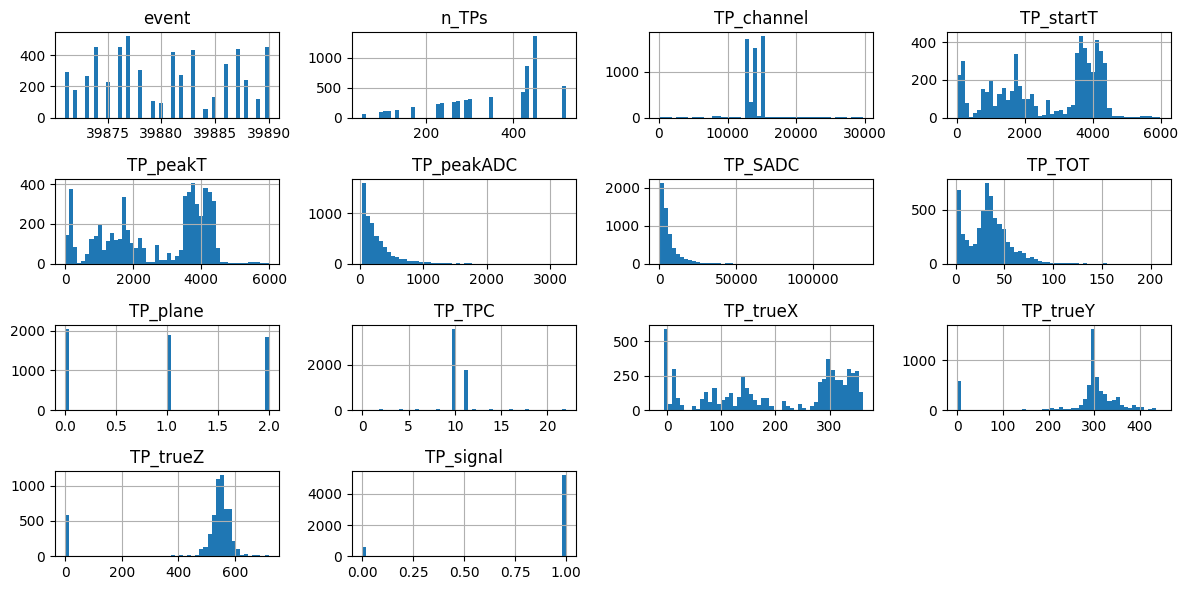

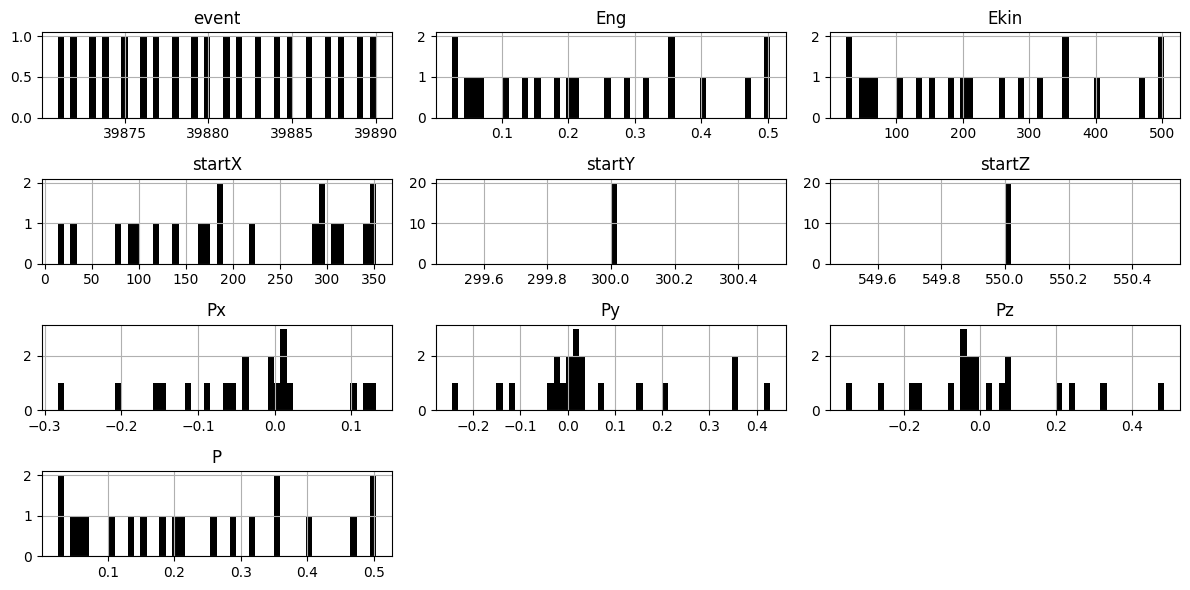

In [39]:
ars.hist(bins = 50, figsize= (12,6))
plt.tight_layout()
plt.show()


mc.hist(bins = 50, figsize=(12,6), color='k')
plt.tight_layout()
plt.show()

# basic event display

/var/folders/1s/mfxsnwp9275ft3r75z4zs6c80000gn/T/ipykernel_72463/368845599.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  s = ax[plane].scatter(x.TP_channel, x.TP_peakT,s=x.TP_TOT/5, c=x.TP_SADC, label = f"{int(mcf.Ekin.values)} MeV electron")


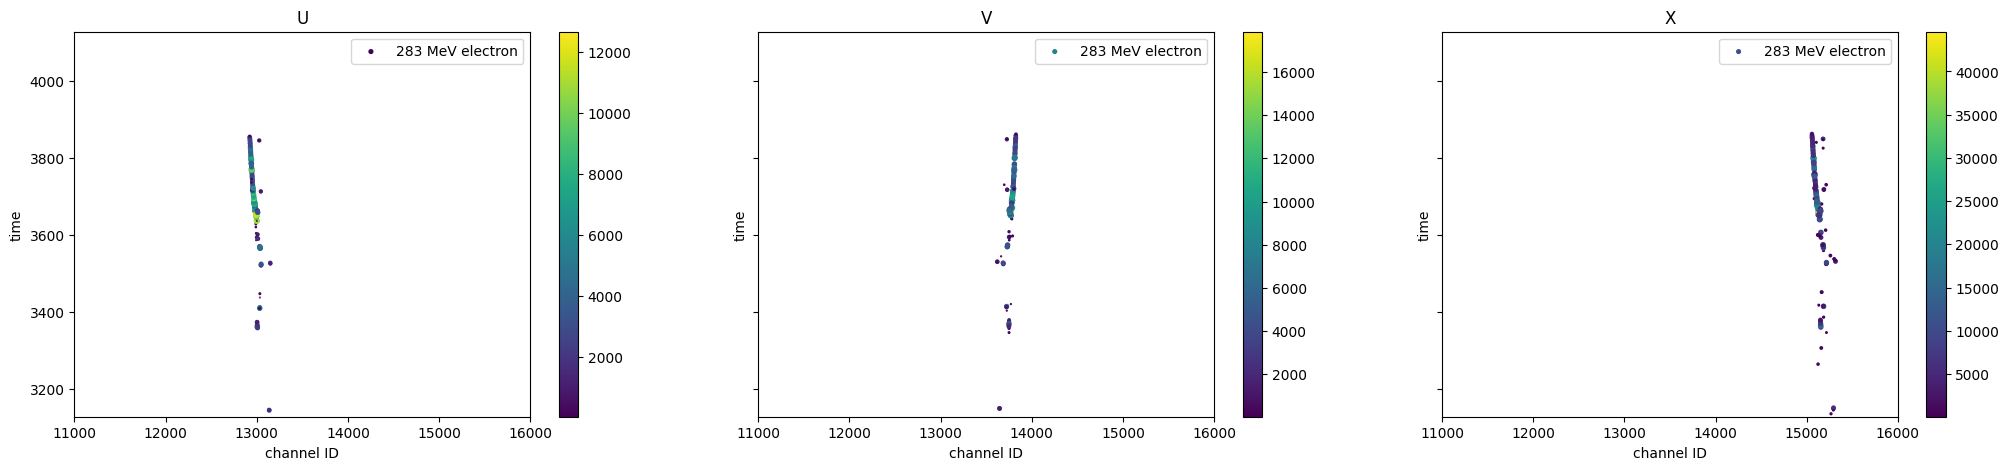

In [35]:
event =events[5]; 
title=['U','V', "X"]
fig, ax = plt.subplots(1,3, figsize=(25,5), sharex = True, sharey= True)
for plane in [0,1,2]:
    x = ars[(ars.event ==event) & (ars.TP_plane ==plane)]
    s = ax[plane].scatter(x.TP_channel, x.TP_peakT,s=x.TP_TOT/5, c=x.TP_SADC, label = f"{int(mcf.Ekin.values)} MeV electron")
    plt.colorbar(s, ax=ax[plane])

mcf = mc[mc.event==event]
for i in range(0,3):
    ax[i].grid(alpha=0)
    ax[i].set_xlim(11e3,16e3)
    ax[i].set_ylim(np.mean(x.TP_peakT.values) -500, np.mean(x.TP_peakT.values) +500 )
    ax[i].set_title(title[i])
    ax[i].set_xlabel("channel ID")
    ax[i].set_ylabel("time")
    ax[i].legend()
plt.show()

# particle energy vs visible energy from TPs

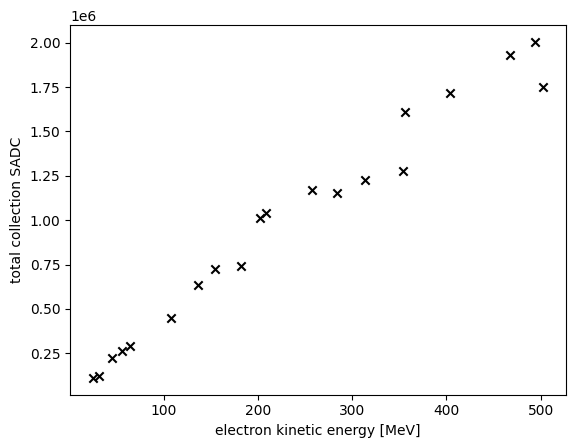

In [13]:
plt.scatter(mc.Ekin, ars[ars.TP_plane==2].groupby('event').TP_SADC.sum(), c='k', marker='x')
plt.ylabel("total collection SADC")
plt.xlabel("electron kinetic energy [MeV]")
plt.show()


# Comparing TP in collection vs. induction plane

Text(0.5, 0, 'Total induction SADC per event')

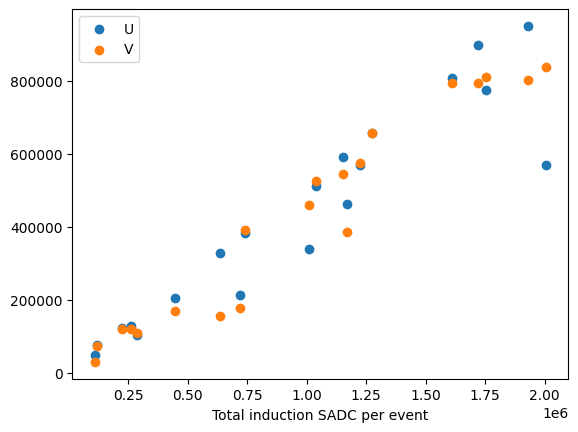

In [9]:
plt.scatter(ars[ars.TP_plane==2].groupby('event').TP_SADC.sum(), ars[ars.TP_plane==0].groupby('event').TP_SADC.sum() , label = 'U')
plt.scatter(ars[ars.TP_plane==2].groupby('event').TP_SADC.sum(), ars[ars.TP_plane==1].groupby('event').TP_SADC.sum() , label ='V')
plt.legend()
plt.xlabel("Total collection SADC per event")
plt.xlabel("Total induction SADC per event")
